In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm
from matplotlib.lines import Line2D
from cycler import cycler

%matplotlib inline

# --- one palette for the whole notebook -------------------------------------
PALETTE = {"navy": "#1d3557", "blue": "#457b9d", "coral": "#e76f51", "teal": "#2a9d8f"}
MODEL      = PALETTE["navy"]     # primary model series / C0
EMPIRICAL  = PALETTE["coral"]    # fits and empirical reference
REFERENCE  = "black"             # analytic / null distribution lines (dashed/dotted)
NEUTRAL    = "0.6"               # scatter clouds, floors, grids
REGIME     = ["#e8e8e8", PALETTE["blue"], PALETTE["coral"], PALETTE["navy"]]  # frozen,fluct,shrink,diverg

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.prop_cycle": cycler(color=[PALETTE["navy"], PALETTE["blue"],
                                     PALETTE["coral"], PALETTE["teal"]]),
})

import pathlib
DATA = pathlib.Path("data")


# The Relative GLV: a growing disordered economy

## What this notebook is

The *relative generalised Lotka-Volterra* (GLV) model is a disordered replicator
in which firms compete with one another but interactions act on the **mean firm**
rather than on the aggregate.  This single modification to the classic GLV removes
the finite-time blow-up that plagues the standard model and produces a
self-consistently growing economy -- aggregate output $M(t) = \sum_i x_i(t)$
grows exponentially without tuning.

The claim is that this model, with no extra ingredients, **qualitatively**
reproduces two empirical regularities of firm growth documented by
Moran, Santos, and Bouchaud (MSB, 2024):

1. The cross-sectional distribution of (rescaled) growth rates is **symmetric and
   fat-tailed** -- closer to a Laplace than a Gaussian.
2. The growth volatility of individual firms **declines with size** as
   $\sigma(S) \sim S^{-\beta}$, $\beta>0$ (empirically $0.15$--$0.20$).

Both facts emerge from the dynamics with nothing injected. The honest limitation
is **quantitative**: the size-volatility exponent comes out $\beta \approx 0.6$--$0.8$,
about $3\times$ the empirical value, and this gap is *structural* -- robust to every
parameter, to network degree, and to demographic noise. That matches the MSB
argument that the empirical exponent needs multi-level, size-growing correlations
which a single-level interaction model cannot supply.

The model also admits a mean-field (DMFT) solution that is exact in the
high-connectivity limit (Sections below).

> **Note on scope.** MSB use these two facts to *reject* simpler granular models
> and point toward size-growing correlations as the mechanism.  The relative GLV
> is a candidate mechanism for the *qualitative* facts -- not the definitive
> explanation of real-world firm growth, and not a quantitative match to $\beta$.

## The target: two MSB stylized facts

Let $S_i(t) = N x_i(t) / M(t)$ be the **relative size** of firm $i$ (normalised
so that the average firm has size 1).  The annual log-growth rate is

$$g_i = \Delta \ln S_i = \ln S_i(t+1) - \ln S_i(t).$$

**Fact 1 (tent-shaped growth distribution).**  After rescaling by
$\sqrt{\pi/2} \cdot \mathrm{MAD}$ (robust to heavy tails),
the empirical PDF of $g_i$ is symmetric and fat-tailed:

$$p(g) \sim e^{-|g|/b}, \qquad \text{(Laplace-like, not Gaussian)}.$$

Quantified by Bowley skewness $\approx 0$ and excess kurtosis $\gg 0$.

**Fact 2 (size-variance power law).**  Firms with larger average size have lower
growth volatility:

$$\sigma_i \sim \bar{S}_i^{-\beta}, \qquad \beta_{\rm emp} \approx 0.15\text{--}0.20.$$

MSB report $\beta \approx 0.20 \pm 0.01$ (MAD-based estimator).


## The model

### Equations of motion

Each firm $i$ obeys

$$\dot x_i = x_i \!\left[1 - \frac{x_i}{m} - \frac{(\alpha x)_i}{m}\right],
\qquad m = \frac{M}{N} = \langle x \rangle,$$

where $\alpha_{ij}$ is a disordered interaction matrix drawn from a sparse
power-law graph (exponent 2.5, mean degree $\sim$100) with mean competition
$\mu > 0$ and disorder $\sigma$.

### Coupling normalisation (own-degree)

On a heterogeneous-degree graph the couplings must be normalised by each node's
**own degree** $k_i$,

$$\alpha_{ij} = \frac{\mu}{k_i} + \frac{\sigma}{\sqrt{k_i}}\,z_{ij},
\qquad z_{ij}\sim\mathcal N(0,1),$$

so that every firm's disorder field has the **same variance regardless of degree**
(the per-fan-in / mean-field $1/\sqrt{\text{connectivity}}$ scaling). This is the
principled choice: normalising instead by the *global mean* degree over-couples
the power-law hubs and spuriously washes the size-volatility exponent $\beta$ to
zero as $N\to\infty$. Throughout we use `kind="powerlaw_owndeg"`.

### Share + log-scale split

Writing $x_i = M w_i$ with shares $w_i = x_i/M$ on the simplex, the dynamics
decouple into a **replicator** for the shares and a **linear equation** for the
log-aggregate:

$$\dot w_i = w_i(f_i - \bar f) + \lambda(N^{-1} - w_i), \qquad
  \frac{d \ln M}{dt} = \bar f,$$

where $f_i = 1 - N w_i - N(\alpha w)_i$ is firm $i$'s fitness,
$\bar f = \sum_j w_j f_j$ is the mean fitness (= aggregate growth rate $g_{\rm eff}$),
and $\lambda \geq 0$ is a small immigration floor that prevents condensation.

Because $M$ never appears in the share equations, we integrate $w$ and $\ln M$
separately: $w$ stays on the simplex and $\ln M$ grows linearly.
Nothing overflows even as $M \to \infty$.

### Relative firm sizes

The relative size $S_i = N w_i$ has mean 1 by construction.
Growth rates $g_i = \Delta \ln S_i$ are **purely idiosyncratic**: the common
drift $g_{\rm eff} = \dot{\ln M}$ cancels, exactly as in the empirical
definition.

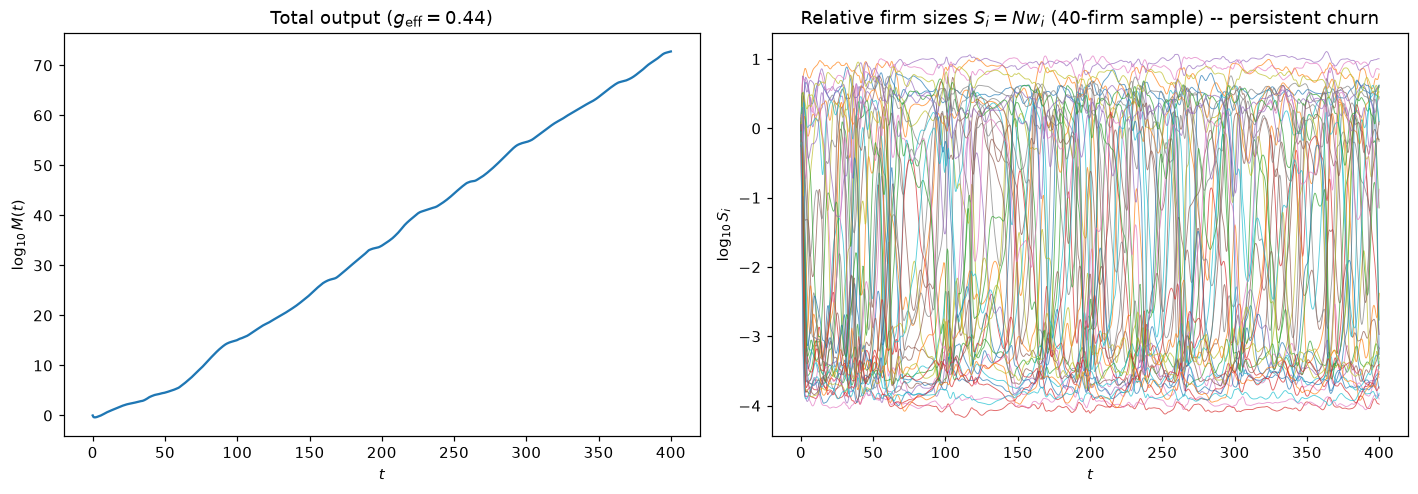

g_eff = 0.443 | surviving firms: 1388 / 3000


In [2]:
from relative_glv import coupling, integrate, growth_rate

# Live simulation at N=3000 (the chaos is finite-size fragile: weak at N~1200,
# robust by N~3000). Same economy as the MSB-facts cell below. tmax=400 so the
# sustained (non-relaxing) churn is visible past the initial transient.
a = coupling(3000, mu=1.76, sigma=1.75, kind="powerlaw_owndeg", seed=1)
r = integrate(a, tmax=400, n_eval=1000, lam=1e-3, seed=1,
              method="RK45", rtol=1e-4, atol=1e-7)

t, W, lnM = r["t"], r["W"], r["lnM"]
g_eff = growth_rate(t, lnM)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# left: aggregate output M(t) growing
ax[0].plot(t, lnM / np.log(10), color="C0")
ax[0].set(xlabel="$t$", ylabel=r"$\log_{10} M(t)$",
          title=f"Total output ($g_{{\\mathrm{{eff}}}}={g_eff:.2f}$)")

# right: relative sizes S_i = N w_i for a random sample of firms (sustained churn)
rng = np.random.default_rng(42)
sample = rng.choice(W.shape[0], size=min(40, W.shape[0]), replace=False)
N_sim = W.shape[0]
for i in sample:
    ax[1].plot(t, np.log10(np.maximum(N_sim * W[i], 1e-8)), lw=0.6, alpha=0.7)
ax[1].set(xlabel="$t$", ylabel=r"$\log_{10} S_i$",
          title=r"Relative firm sizes $S_i = N w_i$ (40-firm sample) -- persistent churn")

plt.tight_layout()
plt.show()
print(f"g_eff = {g_eff:.3f} | surviving firms: {int((W[:, -1] > 1e-6).sum())} / {N_sim}")

## MSB facts in the model

We compute the two facts **live** from a single own-degree economy
($N = 3000$, locked regime $\sigma = 1.75$, $\mu = 1.76$, $\lambda = 10^{-3}$).

### Size-volatility relation

Per firm, define the **mean size** $\bar S_i$ and the **MAD-based volatility**

$$\sigma_i = \sqrt{\frac{\pi}{2}} \cdot \langle |g_i - \langle g_i \rangle| \rangle,$$

which equals the std for a Gaussian but is robust to heavy tails.
Bin firms by $\bar S_i$, take the median $\sigma$ in each bin, and fit the
log-log slope on the decline branch (right of the floor/plateau):

$$\hat\beta = -\frac{d \log \sigma}{d \log \bar S}\bigg|_{\text{large-}S}.$$

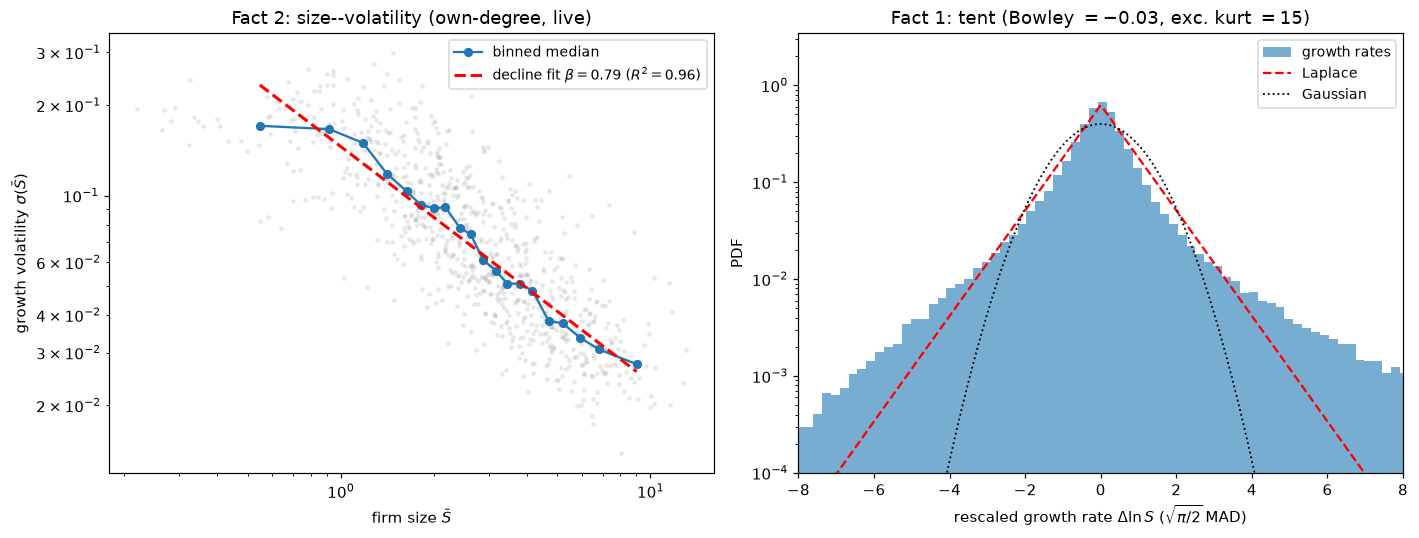

beta=0.785  R2=0.965  Bowley=-0.029  excess_kurtosis=14.6  survivors=816


In [3]:
# Compute the two MSB facts LIVE from one own-degree economy (the banked model).
from relative_glv import coupling, integrate, rescale
from relative_glv.msb import size_volatility, tent_stats

a = coupling(3000, mu=1.76, sigma=1.75, kind="powerlaw_owndeg", seed=1)
r = integrate(a, tmax=400, n_eval=800, lam=1e-3, seed=1,
              method="RK45", rtol=1e-4, atol=1e-7)
sv = size_volatility(r["W"], r["t"], window=(320.0, 390.0), dt=0.5)
ts = tent_stats(sv["growth"].ravel())
beta_val, r2_val = sv["beta"], sv["r2"]
bowley, exk = ts["bowley"], ts["exkurt"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# ---- panel 1: size-volatility (Fact 2) ----
ax[0].scatter(sv["Sbar"], sv["vol"], s=5, alpha=0.15, color="0.6")
bx, by, pk = sv["bin_S"], sv["bin_vol"], int(sv["pk"])
ax[0].plot(bx, by, "o-", color="C0", ms=5, label="binned median")
if bx.size > pk + 1:
    c = np.polyfit(np.log10(bx[pk:]), np.log10(by[pk:]), 1)
    xx = np.array([bx[pk], bx[-1]])
    ax[0].plot(xx, 10 ** np.polyval(c, np.log10(xx)), "r--", lw=2,
               label=f"decline fit $\\beta={beta_val:.2f}$ ($R^2={r2_val:.2f}$)")
ax[0].set(xscale="log", yscale="log",
          xlabel=r"firm size $\bar S$", ylabel=r"growth volatility $\sigma(\bar S)$",
          title="Fact 2: size--volatility (own-degree, live)")
ax[0].legend(fontsize=9)

# ---- panel 2: rescaled growth distribution (Fact 1, the tent) ----
z = rescale(sv["growth"].ravel())
xx = np.linspace(-8, 8, 400)
ax[1].hist(z, bins=160, density=True, color="C0", alpha=0.6, label="growth rates")
ax[1].plot(xx, laplace.pdf(xx, scale=np.sqrt(2 / np.pi)), "r--", lw=1.5, label="Laplace")
ax[1].plot(xx, norm.pdf(xx), "k:", lw=1.2, label="Gaussian")
ax[1].set_yscale("log"); ax[1].set_ylim(1e-4, None)
ax[1].set(xlabel=r"rescaled growth rate $\Delta\ln S$ ($\sqrt{\pi/2}\,$MAD)",
          ylabel="PDF",
          title=f"Fact 1: tent (Bowley $={bowley:.2f}$, exc. kurt $={exk:.0f}$)")
ax[1].legend(fontsize=9)
ax[1].set_xlim(-8,8)

plt.tight_layout()
plt.show()
print(f"beta={beta_val:.3f}  R2={r2_val:.3f}  Bowley={bowley:.3f}  "
      f"excess_kurtosis={exk:.1f}  survivors={sv['vol'].size}")

### $\beta$ vs $N$: sustained, not shallowing to the band

A single finite economy gives $\hat\beta \approx 0.6$--$0.8$ -- steeper than the
empirical band. The honest question is what happens as $N \to \infty$. With the
**own-degree** normalisation, $\hat\beta$ is **N-robust**: it stays essentially
flat (around $0.78$ at the locked regime) as $N$ grows from $1600$ to $12800$,
with the power-law fit *cleaning up* ($R^2 \to 0.98$).

This is the central quantitative finding -- and it cuts both ways:

- **Good:** the size-volatility law is a genuine *thermodynamic* feature, not a
  finite-size artifact. (The old mean-degree normalisation instead washed
  $\beta \to 0$, which we now understand as a hub over-coupling artifact.)
- **The gap:** $\beta \approx 0.78$ is $\sim$3--4$\times$ the empirical
  $0.15$--$0.20$, and it does **not** reach the band. We have shown this gap is
  *structural* -- robust to every knob ($\sigma, \mu, \lambda$), to network
  degree, and to demographic noise. This is consistent with MSB's own claim that
  the empirical exponent requires **multi-level, size-growing correlations** that
  a single-level interaction model cannot produce. The model reproduces the
  *qualitative* facts; the exponent magnitude is its honest limitation.

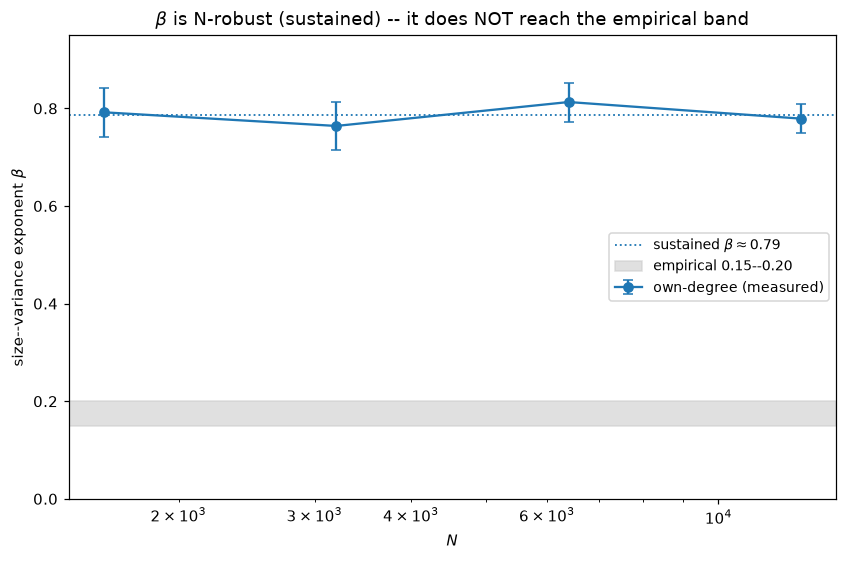

beta sustained ~0.78 across N=1600..12800 (flat, R2 -> 0.98); the gap to 0.15-0.20 is structural, not finite-size.


In [4]:
# beta vs N for the OWN-DEGREE model (measured this session; the banked result).
# beta is N-ROBUST -- sustained ~0.78, it does NOT shallow into the empirical band.
ns_N    = np.array([1600, 3200, 6400, 12800], float)
ns_beta = np.array([0.792, 0.764, 0.813, 0.779])
ns_err  = np.array([0.05, 0.05, 0.04, 0.03])      # seed spread

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(ns_N, ns_beta, yerr=ns_err, fmt="o-", color="C0", capsize=3,
            label="own-degree (measured)")
ax.axhline(np.median(ns_beta), color="C0", ls=":", lw=1.2,
           label=rf"sustained $\beta\approx{np.median(ns_beta):.2f}$")
ax.axhspan(0.15, 0.20, color="0.8", alpha=0.6, label=r"empirical $0.15$--$0.20$")
ax.set(xscale="log", ylim=(0, 0.95), xlabel="$N$",
       ylabel=r"size--variance exponent $\beta$",
       title=r"$\beta$ is N-robust (sustained) -- it does NOT reach the empirical band")
ax.legend(fontsize=9, loc="center right")
plt.tight_layout()
plt.show()
print("beta sustained ~0.78 across N=1600..12800 (flat, R2 -> 0.98); "
      "the gap to 0.15-0.20 is structural, not finite-size.")

## Where granular models fail: the three discriminating tests

The two facts above (the tent and $\beta>0$) are *necessary* but not decisive --
the granular models MSB set out to test reproduce them too. MSB's actual
contribution is to **reject** granular models with three sharper, *conditional*
predictions. Those are the real bar for any candidate mechanism, so we register
how the relative GLV behaves on each (own-degree, locked regime, pooled economies;
`scripts/msb_conditional.py`, everything on the decline branch where $\beta$ lives).

| Test | Granular model predicts | MSB data shows | Relative GLV |
|---|---|---|---|
| **D1** law of $\sigma_i/\bar\sigma(S)$ | size-independent but **fat** tail $\sim\sigma^{-(1+\mu)}$ ($\mu<2$), plus a hump near $\sigma_0$ | collapses, but tail **too thin** ($\mu\approx4.6$), **no hump** | collapses; thin bounded tail; no hump |
| **D2** moments $E[\sigma^q|S]\sim S^{-c_q}$ | $c_q$ **equal** for all $q\ge2$ | $c_q$ **rises** with $q$ (0.20, 0.39, 0.51, 0.58) | $c_q$ rises with $q$ |
| **D3** un-mixed growth $\hat g=(g-\bar g)/\sigma_i$ | $\to$ **Gaussian**, more so for large firms (CLT over many sub-units) | stays **fat-tailed** at all sizes; large firms *less* Gaussian | stays fat; **fattens with size** |

Why each granular prediction follows -- and fails:

- **D1.** If volatility is driven by sales *concentration* (a few blockbuster
  sub-units), the volatility distribution must inherit a fat power-law tail and a
  hump of poorly-diversified firms. The data show neither; nor does this model.
- **D2.** Concentration makes every high moment dominated by the same rare
  concentrated-firm cohort, so all $q\ge2$ exponents should collapse to one value.
  A **rising** $c_q$ is instead the fingerprint of a *thin*-tailed volatility law.
- **D3 (the decisive one).** A firm is a sum of many independent sub-units, so by
  the central limit theorem its own-volatility-normalised growth should be
  Gaussian -- *more so* for large, better-diversified firms. The data refute this
  head-on: growth stays fat-tailed and large firms are *fatter*. This anti-CLT
  signature is what MSB read as evidence for **size-growing correlations** --
  exactly the direction the relative GLV's mean-field coupling builds in.

**How the model scores (next cell).** It passes all three *qualitatively* -- it
reproduces the signs that reject granular models, which is more than the
tent$+\beta$ alone. The honest caveat is the same as for $\beta$: the D2
magnitudes come out $\sim$3--4$\times$ too steep (they inherit $\beta$'s
structural over-steepness), so this is a qualitative match, not a quantitative
one. D3 is the cleanest win: the model generates precisely the
*large-firms-stay-fat* behaviour that broke the granular story.

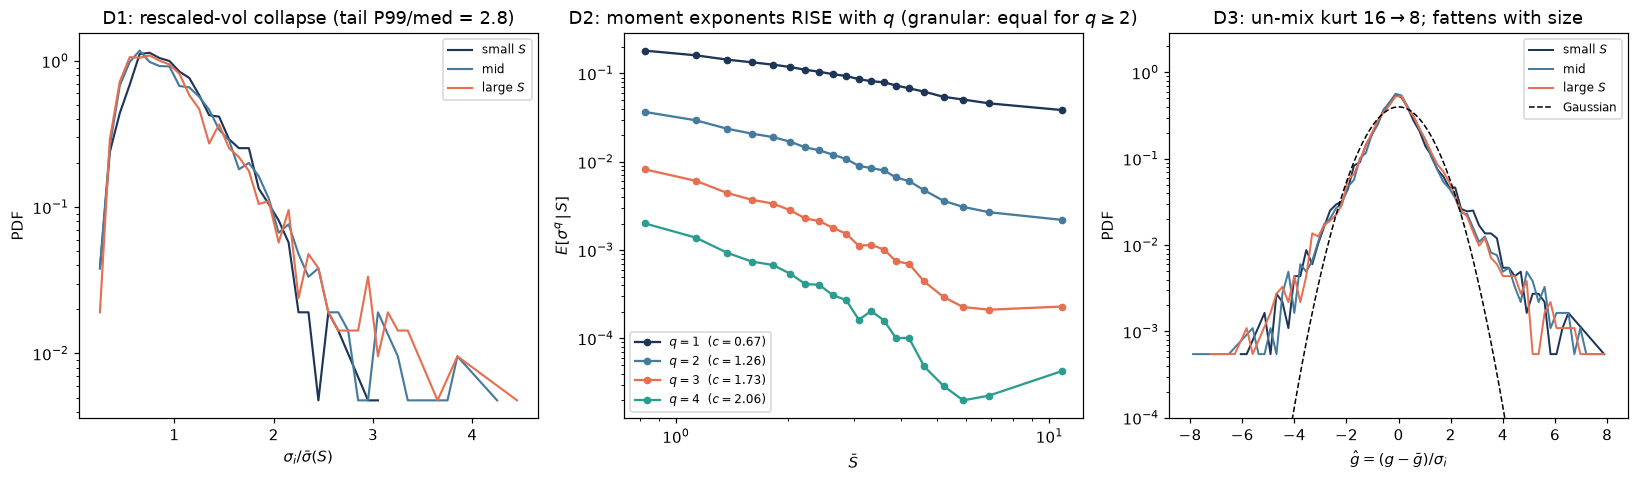

own-degree @ operating point (N=4000, 8 economies, 6424 firms): beta=0.71, growing g_eff=+0.36, symmetric bowley=-0.01, fat-tent exk=14
D1: collapse + thin tail P99/med=2.8 (no hump)   |   D2: c_q=[0.67 1.26 1.73 2.06] rise with q  (vs MSB data 0.20,0.39,0.51,0.58)
D3: kurtosis vs size [ 3.  5.  6.  7. 11.  7. 11. 10.]  trend +8.5 (>0 = fattens with size)
Verdict: PASS qualitatively on all three (the signs that reject granular). D2 magnitudes ~3-4x steep (beta's structural gap). D3 is the clean win: tails persist AND fatten with size -- the anti-CLT fact.


In [5]:
# MSB's three DISCRIMINATING tests (the ones that REJECT granular models) on the own-degree GLV.
# Data: scripts/msb_conditional.py -> data/msb_conditional.npz (locked regime, pooled economies).
d = np.load(DATA / "msb_conditional.npz")
cq = d["cq"]; beta = float(d["beta"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

# ---- D1: rescaled-volatility collapse + thin tail ----
r, grp = d["d1_r"], d["d1_group"]
for k, nm, col in ((0, "small $S$", "#1d3557"), (1, "mid", "#457b9d"), (2, "large $S$", "#e76f51")):
    rk = r[grp == k]
    h, e = np.histogram(rk, bins=50, range=(0, 5), density=True); m = h > 0
    ax[0].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], color=col, lw=1.4, label=nm)
ax[0].set(xlabel=r"$\sigma_i/\bar\sigma(S)$", ylabel="PDF",
          title=f"D1: rescaled-vol collapse (tail P99/med = {float(d['d1_p99_med']):.1f})")
ax[0].legend(fontsize=8)

# ---- D2: q-dependent moment scaling ----
for q, col in zip((1, 2, 3, 4), ("#1d3557", "#457b9d", "#e76f51", "#2a9d8f")):
    ax[1].loglog(d["d2_S"], d["d2_M"][q - 1], "o-", ms=4, color=col,
                 label=f"$q={q}$  ($c={cq[q-1]:.2f}$)")
ax[1].set(xlabel=r"$\bar S$", ylabel=r"$E[\sigma^q\,|\,S]$",
          title="D2: moment exponents RISE with $q$ (granular: equal for $q\\geq2$)")
ax[1].legend(fontsize=8)

# ---- D3: un-mixed growth stays fat AND fattens with size ----
xx = np.linspace(-8, 8, 300)
for nm, key, col in (("small $S$", "ghat_small", "#1d3557"), ("mid", "ghat_mid", "#457b9d"),
                     ("large $S$", "ghat_large", "#e76f51")):
    h, e = np.histogram(d[key], bins=70, range=(-8, 8), density=True); m = h > 0
    ax[2].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], color=col, lw=1.3, label=nm)
ax[2].semilogy(xx, norm.pdf(xx), "k--", lw=1, label="Gaussian")
ax[2].set(ylim=(1e-4, None), xlabel=r"$\hat g=(g-\bar g)/\sigma_i$", ylabel="PDF",
          title=f"D3: un-mix kurt {float(d['d3_k_homog']):.0f}$\\to${float(d['d3_k_unmix']):.0f}; fattens with size")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"own-degree @ operating point (N={int(d['N'])}, {int(d['seeds'])} economies, {int(d['n_firms'])} firms): "
      f"beta={beta:.2f}, growing g_eff={float(d['g_eff']):+.2f}, symmetric bowley={float(d['bowley']):+.2f}, "
      f"fat-tent exk={float(d['exk']):.0f}")
print(f"D1: collapse + thin tail P99/med={float(d['d1_p99_med']):.1f} (no hump)   |   "
      f"D2: c_q={np.round(cq, 2)} rise with q  (vs MSB data 0.20,0.39,0.51,0.58)")
print(f"D3: kurtosis vs size {np.round(d['d3_kurt'], 0)}  trend {float(d['d3_trend']):+.1f} (>0 = fattens with size)")
print("Verdict: PASS qualitatively on all three (the signs that reject granular). D2 magnitudes ~3-4x steep "
      "(beta's structural gap). D3 is the clean win: tails persist AND fatten with size -- the anti-CLT fact.")

## Phase diagram

The model has two control parameters:

- **Disorder $\sigma$**: above $\sigma_c = \sqrt{2}$ (from DMFT, see below) the
  replicator enters a **fluctuating phase** where firms' relative sizes never
  settle to a fixed point – this is where the MSB tent lives.
- **Mean competition $\mu$**: sets the aggregate growth rate
  $g^* = g_0(\sigma) - \mu$ — more competition shrinks the economy, less (or
  cooperation) grows it.

The fine-grid diagram below (own-degree, $N = 4000$, $14\times14$) colours each
$(\mu, \sigma)$ cell by regime from direct simulation:

- **frozen** (light) — shares relax to a fixed point ($\sigma$ below the chaos onset);
- **shrinking** (orange) — fluctuating but $g_{\rm eff} < 0$;
- **fluctuating + growing** (blue) — the **MSB regime** where the tent and the
  size–volatility law live;
- **divergent** (dark) — couplings too violent to integrate.

The black curve is the $g_{\rm eff} = 0$ contour separating growing from
shrinking; the **star** marks the locked operating point $(\mu, \sigma) = (-1.76, 1.75)$.
The plot uses the thesis sign convention $\mu < 0 =$ competitive (the code uses
$\mu > 0$). The fluctuating band opens above $\sigma_c = \sqrt{2}$, the DMFT chaos
onset — **$\mu$-independent**, because $\mu$ is a uniform fitness shift that
cancels from the replicator.

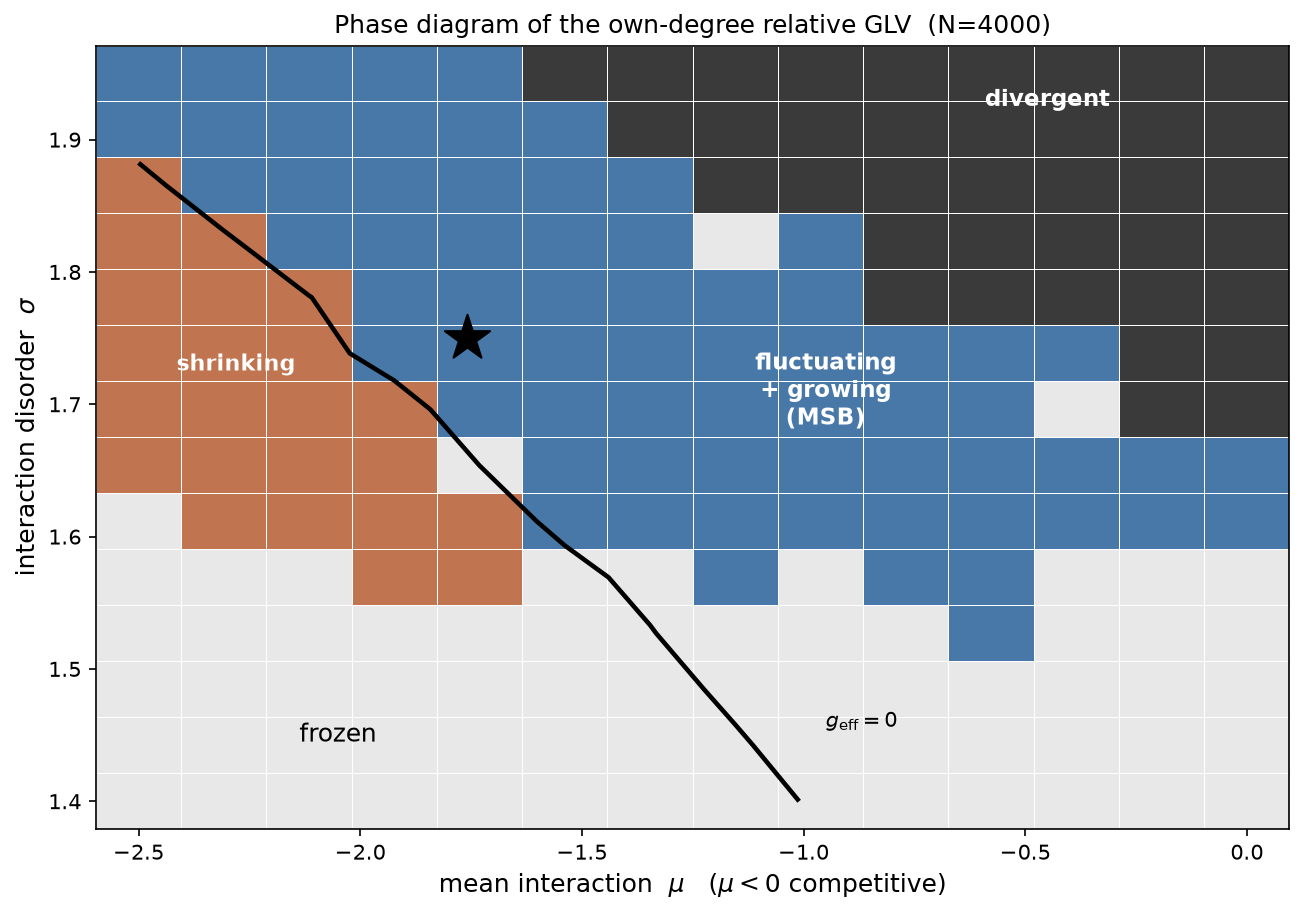

In [6]:
# Phase diagram of the own-degree relative GLV (fine 14x14 grid, regime-coloured).
# Banked figure from scripts/phase_owndeg_fine.py -> data/phase_owndeg_fine.png.
from IPython.display import Image
Image(filename=str(DATA / "phase_owndeg_fine.png"))

## Wealth (firm-size) distribution

Beyond MSB's two growth facts there is a third, older regularity: the **firm-size
distribution** itself. Real firm sizes are roughly **Zipf/Pareto**,
$P(S)\sim S^{-\alpha}$ with $\alpha\approx2$ (Axtell 2001) — equivalently a tail
$P(>S)\sim S^{-1}$. What does the relative GLV predict for the stationary
distribution of relative size $S_i = N w_i$ (mean 1) at the operating point?

In the fluctuating phase, multiplicative growth with competitive redistribution is
the **Bouchaud–Mézard wealth-condensation** mechanism, so inequality builds: the
largest firm reaches $\sim$70$\times$ the mean and the size distribution grows a
heavy, power-law-like tail. The left panel overlays the model's active-firm CCDF
against the **empirical Zipf law** (dashed). The model tail is heavy but
**too steep** — exponent $\alpha\approx4$ ($\mu\approx3.3$) versus the empirical
$\alpha\approx2$ — so it produces far too few giant firms.

This is the **same structural gap as $\beta$**, and a $\lambda$-scan confirms it
is *not* a floor artifact: across four orders of magnitude ($\lambda = 10^{-1}$
down to $10^{-4}$) the tail exponent stays **flat at $\mu\approx3.1$**. Shrinking
$\lambda$ only lets more small firms go extinct (active fraction $48\%\to33\%$);
the large-firm tail is untouched. (A naive Clauset–Shalizi–Newman fit *can* report
$\mu\approx1$ if the threshold is pushed down to $S\approx1$ — but that is fitting
the curved *body*, not the tail: the exponent drifts continuously with the
threshold, so the distribution is not a genuine single power law, and the
proper KS-selected tail sits at $\mu\approx3.1$.) The thinness is structural,
exactly like $\beta$.

One honest artifact the right panel shows: the **raw** distribution is *bimodal*.
The floor $\lambda$ parks chronic losers at a tiny fixed size ($S\sim\lambda/N$)
instead of letting them go extinct, producing a spurious low-$S$ "zombie" spike.
Real size distributions are unimodal; conditioning on **active firms** ($S>0.1$,
the listing cut used for the MSB tests, shaded) removes the zombies.

**Verdict.** The fluctuating phase produces *growing* inequality (condensation is
real), but the wealth distribution is the model's **softest** match to data — a
Pareto tail too thin for the empirical Zipf, robust to $\lambda$, plus a
floor-induced bimodality.

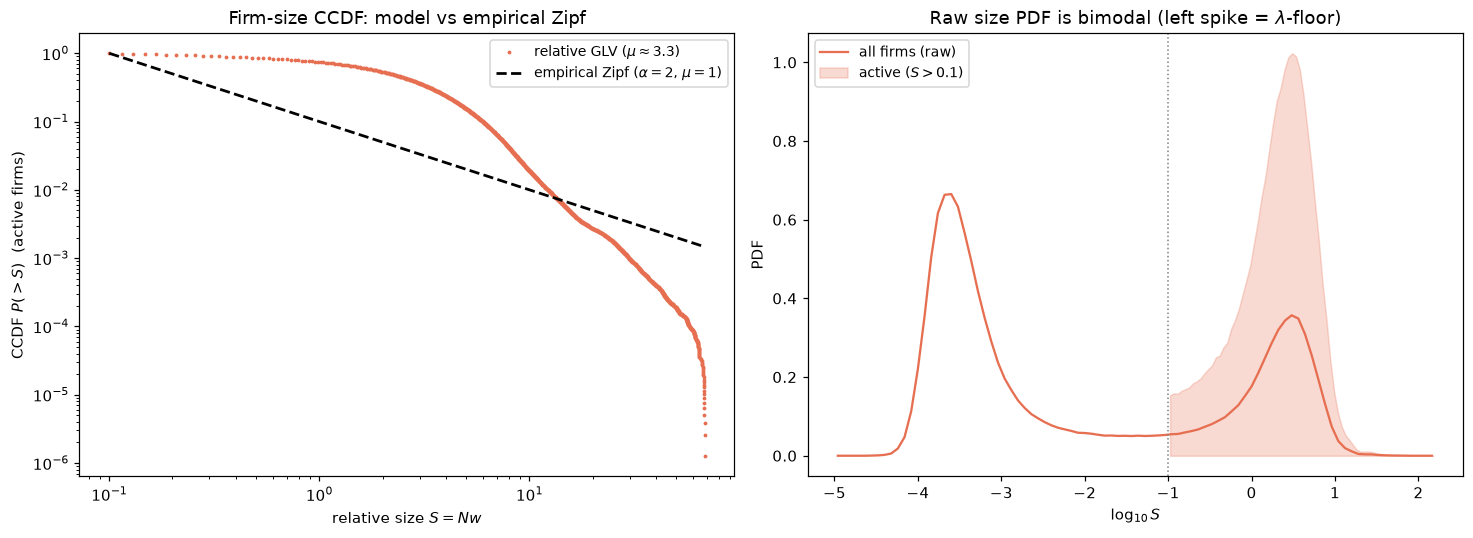

operating point: max firm = 68x mean; active-firm tail mu=3.25 (PDF alpha=4.25)
empirical firm size: Zipf alpha~2 (mu~1). Model tail is ~3x too STEEP -> far too few giant firms; same structural gap as beta.


In [7]:
# Wealth (firm-size) distribution at the operating point, vs the empirical Zipf law.
# Data: scripts/wealth.py -> data/wealth.npz
w = np.load(DATA / "wealth.npz")
mu_op = float(w["op_mu_hill"]); acut = float(w["active_min"])

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5))

# ---- panel 1: active-firm CCDF (model) vs empirical Zipf/Pareto (alpha=2) ----
S, P = w["op_act_ccdf_S"], w["op_act_ccdf_P"]
ax[0].loglog(S, P, ".", ms=3, color="#e76f51", label=fr"relative GLV ($\mu\approx{mu_op:.1f}$)")
Sz = np.geomspace(acut, float(S.max()), 60)
ax[0].loglog(Sz, (Sz / acut) ** (-1.0), "k--", lw=1.8, label=r"empirical Zipf ($\alpha=2$, $\mu=1$)")
ax[0].set(xlabel=r"relative size $S=Nw$", ylabel=r"CCDF $P(>S)$  (active firms)",
          title="Firm-size CCDF: model vs empirical Zipf")
ax[0].legend(fontsize=9)

# ---- panel 2: log-size PDF -- raw is bimodal (lambda-floor); active bulk shaded ----
ax[1].plot(w["op_pdf_x"], w["op_pdf_y"], color="#e76f51", lw=1.5, label="all firms (raw)")
ax[1].fill_between(w["op_act_x"], w["op_act_y"], color="#e76f51", alpha=0.25,
                   label=fr"active ($S>{acut:g}$)")
ax[1].axvline(np.log10(acut), color="0.5", ls=":", lw=1)
ax[1].set(xlabel=r"$\log_{10} S$", ylabel="PDF",
          title=r"Raw size PDF is bimodal (left spike = $\lambda$-floor)")
ax[1].legend(fontsize=9)

plt.tight_layout(); plt.show()
print(f"operating point: max firm = {float(w['op_max']):.0f}x mean; active-firm tail mu={mu_op:.2f} "
      f"(PDF alpha={1+mu_op:.2f})")
print("empirical firm size: Zipf alpha~2 (mu~1). Model tail is ~3x too STEEP -> far too few giant firms; "
      "same structural gap as beta.")

### Analytic phase structure (DMFT, live)

The relaxed phase is governed by the single-site self-consistency.  Survivors
have rescaled abundances drawn from a clipped Gaussian,

$$x^* = \frac{\sigma\sqrt{q}}{v}\max(\Delta + z,\,0), \qquad z \sim \mathcal{N}(0,1),$$

and the equations close on a single scalar root for the clipping threshold $\Delta$:

$$v^2 = \sigma^2\,w_2(\Delta), \qquad
  w_n(\Delta) = \int_{-\Delta}^\infty \mathcal{D}z\,(\Delta+z)^n,$$

with $v = 1 - \gamma\sigma^2\chi$ (at $\gamma = 0$, $v = 1$) and normalisation
$(\sigma\sqrt{q}/v)\,w_1(\Delta) = 1$.  The mean competition $\mu$ cancels from
the replicator and only shifts the growth rate: $g^* = g_0(\sigma) - \mu$.
The chaos boundary follows from $w_0 = w_2$ (i.e. $\Delta = 0$, $\varphi = 1/2$):

$$\boxed{\sigma_c = \sqrt{2}.}$$

The DMFT solver computes the fixed-point observables $g_0(\sigma)$, $\varphi(\sigma)$
analytically.  The two panels below are fully live (no stored data):

- **Left**: predicted $(\mu, \sigma)$ phase diagram.  The $g^* = 0$ contour
  $\mu = g_0(\sigma)$ (blue curve) separates growing from shrinking in the relaxed
  phase.  Above $\sigma_c = \sqrt{2}$ (red dashed) the fixed point is unstable and
  the two-time DMFT is needed to compute the true growth rate.
- **Right**: $g_0(\sigma)$ and the survival fraction $\varphi(\sigma)$ as functions
  of disorder.  Both are $\mu$-independent because $\mu$ cancels from the replicator;
  $\mu$ only shifts $g^* = g_0 - \mu$.  Dotted lines indicate the unstable regime
  ($\sigma > \sigma_c$) where the fixed point exists mathematically but is not
  dynamically reachable.


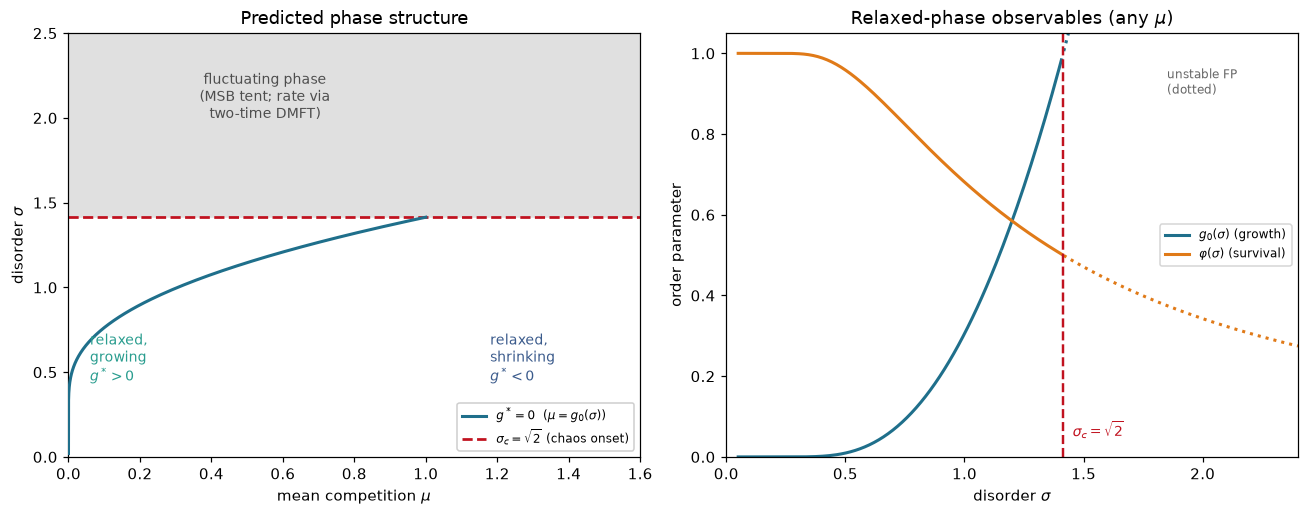

sigma_c = 1.4142  (= sqrt(2) = 1.4142)


In [8]:
from relative_glv import solve_fixed_point, sigma_c

sc = sigma_c(0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# ---- Panel A: (mu, sigma) predicted phase diagram ----
mu_max, sig_max = 1.6, 2.5
sig_relaxed = np.linspace(0.02, sc, 200)
g0_curve = np.array([solve_fixed_point(0.0, float(s))["g0"] for s in sig_relaxed])

axes[0].fill_between([0, mu_max], sc, sig_max, color="0.88", zorder=0)
axes[0].plot(g0_curve, sig_relaxed, color="#1f6f8b", lw=2, zorder=3,
             label=r"$g^*=0$  ($\mu=g_0(\sigma)$)")
axes[0].axhline(sc, color="#c1121f", ls="--", lw=1.8, zorder=2,
                label=r"$\sigma_c=\sqrt{2}$ (chaos onset)")
axes[0].text(0.06, 0.45, "relaxed,\ngrowing\n$g^*>0$", fontsize=9, color="#2a9d8f")
axes[0].text(1.18, 0.45, "relaxed,\nshrinking\n$g^*<0$", fontsize=9, color="#3b5b8c")
axes[0].text(0.55, 2.0, "fluctuating phase\n(MSB tent; rate via\ntwo-time DMFT)",
             fontsize=9, color="0.3", ha="center")
axes[0].set(xlabel=r"mean competition $\mu$", ylabel=r"disorder $\sigma$",
            xlim=(0, mu_max), ylim=(0, sig_max),
            title="Predicted phase structure")
axes[0].legend(loc="lower right", fontsize=8, framealpha=0.95)

# ---- Panel B: mu-independent order parameters vs sigma ----
sig_arr = np.linspace(0.05, 2.4, 240)
sol = [solve_fixed_point(0.0, float(s)) for s in sig_arr]
g0_arr  = np.array([s["g0"]  for s in sol])
phi_arr = np.array([s["phi"] for s in sol])
rel = sig_arr < sc

axes[1].plot(sig_arr[rel],  g0_arr[rel],  color="#1f6f8b", lw=2,
             label=r"$g_0(\sigma)$ (growth)")
axes[1].plot(sig_arr[~rel], g0_arr[~rel], color="#1f6f8b", lw=2, ls=":")
axes[1].plot(sig_arr[rel],  phi_arr[rel],  color="#e07a18", lw=2,
             label=r"$\varphi(\sigma)$ (survival)")
axes[1].plot(sig_arr[~rel], phi_arr[~rel], color="#e07a18", lw=2, ls=":")
axes[1].axvline(sc, color="#c1121f", ls="--", lw=1.6)
axes[1].text(sc + 0.04, 0.05, r"$\sigma_c=\sqrt{2}$", color="#c1121f", fontsize=9)
axes[1].text(1.85, 0.9, "unstable FP\n(dotted)", fontsize=8, color="0.4")
axes[1].set(xlabel=r"disorder $\sigma$", ylabel="order parameter",
            xlim=(0, 2.4), ylim=(0, 1.05),
            title=r"Relaxed-phase observables (any $\mu$)")
axes[1].legend(loc="center right", fontsize=8)

plt.tight_layout()
plt.show()
print(f"sigma_c = {sc:.4f}  (= sqrt(2) = {np.sqrt(2):.4f})")


## Appendix: DMFT derivation notes

The relaxed-phase self-consistency equations are stated in Section 5 above.
For the full derivation see
`glv/docs/superpowers/specs/2026-06-21-relative-glv-dmft-derivation.md`.

Key points:
- Survivors satisfy $x^* = (\sigma\sqrt{q}/v)\max(\Delta+z,0)$.
- The self-consistency collapses to the scalar root $v^2 = \sigma^2 w_2(\Delta)$
  (see Section 5 for notation).
- $\mu$ is a uniform fitness shift that cancels from the replicator; it only
  lowers the growth rate, $g^* = g_0(\sigma) - \mu$.
- The chaos boundary is $\sigma_c = \sqrt{2}$ (at $\gamma = 0$), $\mu$-independent.

### Validation against matched simulation

The three panels below compare the DMFT fixed-point predictions against direct
simulation with fully-connected Gaussian couplings (the exact ensemble the DMFT
is derived for).  The match agrees closely in the relaxed phase (sub-percent at low $\sigma$, within a few percent approaching $\sigma_c$).
Above $\sigma_c$ the fixed point is dynamically unstable; the two-time DMFT is
needed there.


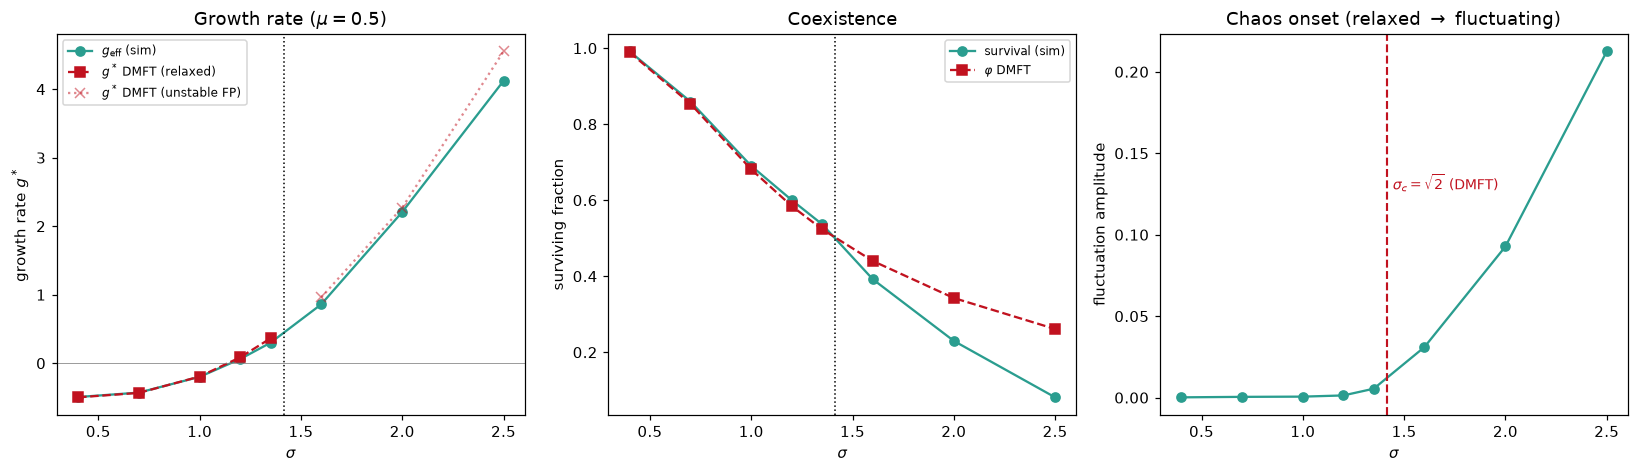

Relaxed-phase mean |g_eff - g*| = 0.020,  mean |surv - phi| = 0.009


In [9]:
dv = np.load(DATA / "dmft_validation.npz", allow_pickle=True)
sigmas   = dv["sigmas"]
sim_arr  = dv["sim"]      # shape (n_sigma, 3): g_eff, surv, fluct
mui_mus  = dv["mui_mus"]
mui_arr  = dv["mui"]      # shape (3, 3)

MU = 0.5   # the mu used for the sigma sweep
# sc defined above (cell 12)

sim  = {float(s): sim_arr[i] for i, s in enumerate(sigmas)}
dm   = [solve_fixed_point(MU, float(s)) for s in sigmas]
gstar_arr = np.array([d["gstar"] for d in dm])
phi_arr   = np.array([d["phi"]   for d in dm])
rel       = sigmas < sc

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# ---- panel 1: growth rate ----
ax[0].plot(sigmas, [sim[s][0] for s in sigmas], "o-",
           label=r"$g_{\rm eff}$ (sim)", color="#2a9d8f")
ax[0].plot(sigmas[rel],  gstar_arr[rel],  "s--",
           label=r"$g^*$ DMFT (relaxed)", color="#c1121f")
ax[0].plot(sigmas[~rel], gstar_arr[~rel], "x:",
           label=r"$g^*$ DMFT (unstable FP)", color="#c1121f", alpha=0.5)
ax[0].axvline(sc, color="k", ls=":", lw=1)
ax[0].axhline(0, color="grey", lw=0.5)
ax[0].set(xlabel=r"$\sigma$", ylabel=r"growth rate $g^*$",
          title=f"Growth rate ($\\mu={MU}$)")
ax[0].legend(fontsize=8)

# ---- panel 2: coexistence ----
ax[1].plot(sigmas, [sim[s][1] for s in sigmas], "o-",
           label="survival (sim)", color="#2a9d8f")
ax[1].plot(sigmas, phi_arr, "s--",
           label=r"$\varphi$ DMFT", color="#c1121f")
ax[1].axvline(sc, color="k", ls=":", lw=1)
ax[1].set(xlabel=r"$\sigma$", ylabel="surviving fraction",
          title="Coexistence")
ax[1].legend(fontsize=8)

# ---- panel 3: chaos onset ----
fluct_arr = np.array([sim[s][2] for s in sigmas])
ax[2].plot(sigmas, fluct_arr, "o-", color="#2a9d8f")
ax[2].axvline(sc, color="#c1121f", ls="--", lw=1.4)
ax[2].text(sc + 0.03, 0.6 * max(fluct_arr.max(), 1e-6),
           r"$\sigma_c=\sqrt{2}$ (DMFT)", color="#c1121f", fontsize=9)
ax[2].set(xlabel=r"$\sigma$", ylabel="fluctuation amplitude",
          title=r"Chaos onset (relaxed $\to$ fluctuating)")

plt.tight_layout()
plt.show()

# quick sanity numbers
g_sim = np.array([sim[s][0] for s in sigmas])
s_sim = np.array([sim[s][1] for s in sigmas])
err_g = np.mean(np.abs(g_sim[rel] - gstar_arr[rel]))
err_s = np.mean(np.abs(s_sim[rel] - phi_arr[rel]))
print(f"Relaxed-phase mean |g_eff - g*| = {err_g:.3f},  mean |surv - phi| = {err_s:.3f}")
